# Hybrid Sentiment Analysis

In [2]:
pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.2 MB/s eta 0:00:00


In [3]:
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

# 1. Initialize tools
vader_analyzer = SentimentIntensityAnalyzer()
# Default model: distilbert-base-uncased-finetuned-sst-2-english
transformer_pipeline = pipeline("sentiment-analysis")

# 2. Sample data
data = {
    'text': [
        "I LOVE this new update!!! 😊",
        "The battery life is decent, but the screen is too dim.",
        "The package arrived late and the box was damaged.",
        "The movie was okay, nothing special."
    ]
}
df = pd.DataFrame(data)

# 3. Apply VADER
df['vader_score'] = df['text'].apply(lambda x: vader_analyzer.polarity_scores(x)['compound'])

# 4. Apply TextBlob
df['blob_polarity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df['blob_subjectivity'] = df['text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# 5. Apply Transformers (Hugging Face)
def get_tf_sentiment(text):
    result = transformer_pipeline(text)[0]
    # Convert label to numeric for easier comparison (optional)
    score = result['score'] if result['label'] == 'POSITIVE' else -result['score']
    return score

df['transformer_score'] = df['text'].apply(get_tf_sentiment)

print(df[['text', 'vader_score', 'blob_polarity', 'transformer_score']])


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

                                                text  vader_score  \
0                        I LOVE this new update!!! 😊       0.9154   
1  The battery life is decent, but the screen is ...       0.0000   
2  The package arrived late and the box was damaged.      -0.4404   
3               The movie was okay, nothing special.      -0.0920   

   blob_polarity  transformer_score  
0       0.383168           0.999864  
1       0.133333          -0.999494  
2      -0.300000          -0.999657  
3       0.428571          -0.992512  


In [5]:
from transformers import pipeline

# Load the Twitter-specific model
# This model uses labels: 0 -> Negative, 1 -> Neutral, 2 -> Positive
twitter_pipe = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment-latest")

def get_twitter_sentiment(text):
    result = twitter_pipe(text)[0]
    label = result['label'].lower()
    score = result['score']

    # Mapping to a -1 to 1 scale for consistency with your existing scores
    if label == 'positive':
        return score
    elif label == 'negative':
        return -score
    else:
        return 0 # Neutral is returned as 0

# Apply to your existing DataFrame
df['twitter_roberta_score'] = df['text'].apply(get_twitter_sentiment)

print(df[['text', 'vader_score', 'twitter_roberta_score']])


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

                                                text  vader_score  \
0                        I LOVE this new update!!! 😊       0.9154   
1  The battery life is decent, but the screen is ...       0.0000   
2  The package arrived late and the box was damaged.      -0.4404   
3               The movie was okay, nothing special.      -0.0920   

   twitter_roberta_score  
0               0.989966  
1               0.000000  
2              -0.881095  
3               0.000000  


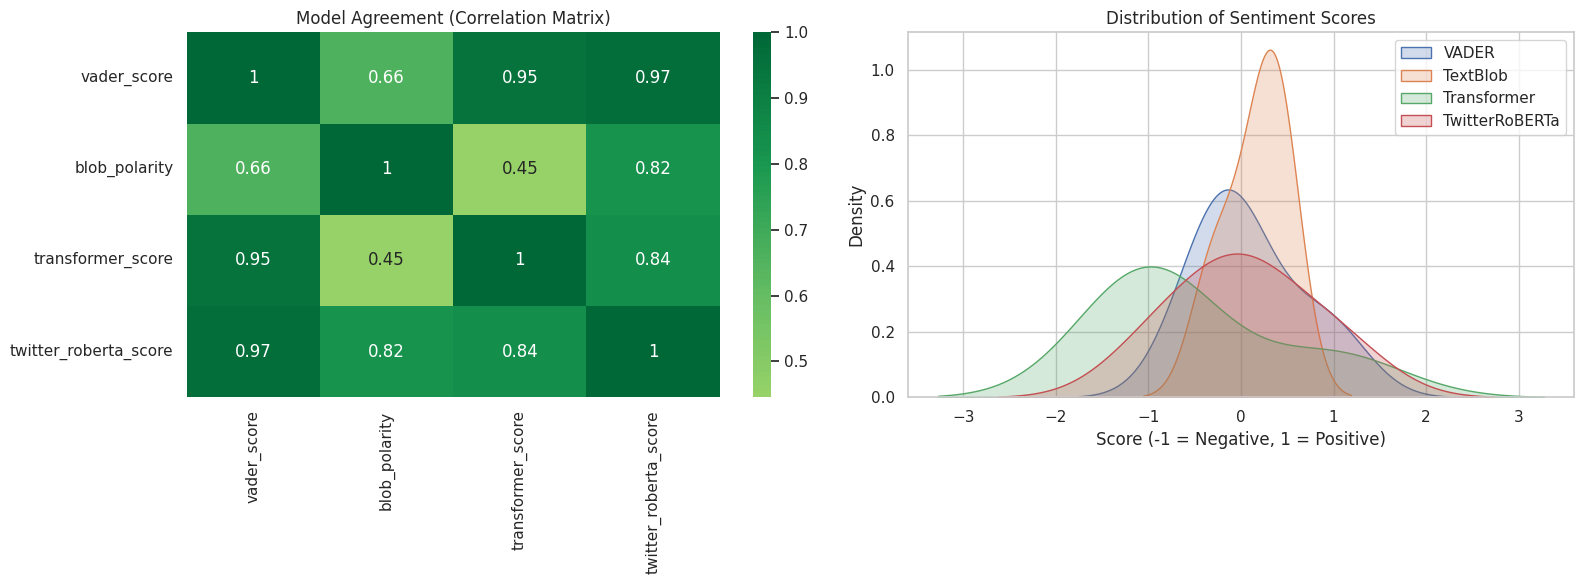

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. Correlation Heatmap
# This shows how much the models "agree" with each other
corr = df[['vader_score', 'blob_polarity', 'transformer_score', 'twitter_roberta_score']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, ax=ax1)
ax1.set_title('Model Agreement (Correlation Matrix)')

# 2. Distribution Plot (KDE)
# This shows the "bias" or spread of each model
sns.kdeplot(df['vader_score'], label='VADER', fill=True, ax=ax2)
sns.kdeplot(df['blob_polarity'], label='TextBlob', fill=True, ax=ax2)
sns.kdeplot(df['transformer_score'], label='Transformer', fill=True, ax=ax2)
sns.kdeplot(df['twitter_roberta_score'], label='TwitterRoBERTa', fill=True, ax=ax2)

ax2.set_title('Distribution of Sentiment Scores')
ax2.set_xlabel('Score (-1 = Negative, 1 = Positive)')
ax2.legend()

plt.tight_layout()
plt.show()


In [7]:
import numpy as np

# 1. Categorise scores into buckets: Negative (-1 to -0.05), Neutral (-0.05 to 0.05), Positive (0.05 to 1)
def get_label(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

df['vader_label'] = df['vader_score'].apply(get_label)
df['roberta_label'] = df['twitter_roberta_score'].apply(get_label)

# 2. Calculate the Percentage Agreement
agreement_rate = (df['vader_label'] == df['roberta_label']).mean() * 100

print(f"Model Agreement Rate: {agreement_rate}%")

# 3. Show where they disagree (The "Deep Exploration" goldmine)
disagreements = df[df['vader_label'] != df['roberta_label']]
print("\nDiscrepancies found:")
print(disagreements[['text', 'vader_label', 'roberta_label']])


Model Agreement Rate: 75.0%

Discrepancies found:
                                   text vader_label roberta_label
3  The movie was okay, nothing special.    Negative       Neutral
